# Clinical NER Pipeline: BERT and BERT + GENIA

GENIA data is used as negative-sample augmentation by assigning all GENIA tokens the label `O`.

## Step 0: Environment Setup


In [ ]:
# Kaggle / notebook environment setup
!pip install -q \
  "transformers==4.46.3" \
  "accelerate==0.34.2" \
  "peft==0.13.2" \
  "datasets" \
  "evaluate==0.4.3" \
  "seqeval==1.2.2" \
  "scikit-learn"

print("If this is the first run in a fresh session, restart the Kaggle session after installation.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 99.9 MB/s eta 0:00:00
If this is the first run in a fresh session, restart the Kaggle session after installation.


In [ ]:
import os
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from evaluate import load
from sklearn.metrics import confusion_matrix

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# project paths
PROJECT_DIR = "/kaggle/input/datasets/shinjinisupakar/clinicalnlp"
BC5CDR_DIR = os.path.join(PROJECT_DIR, "Processed_Data", "Processed_Data", "ner", "bc5cdr")
GENIA_DIR = os.path.join(PROJECT_DIR, "Processed_Data", "Processed_Data", "triggers", "genia")
OUTPUT_DIR = "/kaggle/working"

BERT_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_bert")
BERT_GENIA_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "results_bert_genia")

print("BC5CDR_DIR exists:", os.path.exists(BC5CDR_DIR))
print("GENIA_DIR exists:", os.path.exists(GENIA_DIR))
print("Using device:", "cuda" if torch.cuda.is_available() else "cpu")


2026-04-11 19:12:59.945299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775934780.126290      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775934780.186323      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775934780.605471      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775934780.605506      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775934780.605508      22 computation_placer.cc:177] computation placer alr

BC5CDR_DIR exists: True
GENIA_DIR exists: True
Using device: cuda


## Step 1: Data Loading and Inspection



In [ ]:
def load_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl(os.path.join(BC5CDR_DIR, "train.jsonl"))
val_data = load_jsonl(os.path.join(BC5CDR_DIR, "validation.jsonl"))
test_data = load_jsonl(os.path.join(BC5CDR_DIR, "test.jsonl"))
genia_train_raw = load_jsonl(os.path.join(GENIA_DIR, "train.jsonl"))

print(f"Loaded BC5CDR train: {len(train_data)}")
print(f"Loaded BC5CDR validation: {len(val_data)}")
print(f"Loaded BC5CDR test: {len(test_data)}")
print(f"Loaded GENIA train: {len(genia_train_raw)}")


Loaded BC5CDR train: 5228
Loaded BC5CDR validation: 5330
Loaded BC5CDR test: 5865
Loaded GENIA train: 7388


In [ ]:
all_labels = [label for doc in train_data for label in doc["labels"]]
label_counts = Counter(all_labels)

print("Label distribution in BC5CDR training set:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

seq_lengths = [len(doc["tokens"]) for doc in train_data]
print(f"\nSequence length statistics")
print(f"  Mean: {np.mean(seq_lengths):.2f}")
print(f"  Max : {np.max(seq_lengths)}")
print(f"  Min : {np.min(seq_lengths)}")

print("\nSample BC5CDR training example:")
sample = train_data[0]
for token, label in zip(sample["tokens"][:40], sample["labels"][:40]):
    print(f"{token:20} {label}")


Label distribution in BC5CDR training set:
  B-Chemical: 5203
  O: 96796
  B-Disease: 4182
  I-Disease: 2570
  I-Chemical: 571

Sequence length statistics
  Mean: 20.91
  Max : 133
  Min : 1

Sample BC5CDR training example:
Naloxone             B-Chemical
reverses             O
the                  O
antihypertensive     O
effect               O
of                   O
clonidine            B-Chemical
.                    O


## Step 2: Label Setup, Tokenizer, and Label Alignment



In [ ]:
label_names = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}

checkpoint_bert = "bert-base-cased"
tokenizer_bert = AutoTokenizer.from_pretrained(checkpoint_bert)

print("Label mapping:", label2id)
print("Loaded tokenizer for:", checkpoint_bert)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Label mapping: {'O': 0, 'B-Chemical': 1, 'I-Chemical': 2, 'B-Disease': 3, 'I-Disease': 4}
Loaded tokenizer for: bert-base-cased


In [ ]:
def tokenize_and_align_labels(examples, tokenizer):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True,
    )

    aligned_labels = []
    for i, labels in enumerate(examples["labels"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[labels[word_idx]])
            else:
                current_label = labels[word_idx]
                if current_label.startswith("B-"):
                    current_label = "I-" + current_label[2:]
                label_ids.append(label2id[current_label])
            previous_word_idx = word_idx

        aligned_labels.append(label_ids)

    tokenized_inputs["labels"] = aligned_labels
    return tokenized_inputs

def align_bert(examples):
    return tokenize_and_align_labels(examples, tokenizer_bert)


## Step 3: Dataset Preparation



In [ ]:
def create_hf_dataset(data):
    return Dataset.from_dict({
        "tokens": [x["tokens"] for x in data],
        "labels": [x["labels"] for x in data],
    })

bc5cdr_dataset = DatasetDict({
    "train": create_hf_dataset(train_data),
    "validation": create_hf_dataset(val_data),
    "test": create_hf_dataset(test_data),
})

bc5cdr_dataset


DatasetDict({
    train: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5228
    })
    validation: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5330
    })
    test: Dataset({
        features: ['tokens', 'labels'],
        num_rows: 5865
    })
})

In [ ]:
bert_dataset = bc5cdr_dataset.map(
    align_bert,
    batched=True,
    remove_columns=["tokens", "labels"]
)

print("BERT train shape:", bert_dataset["train"].shape)


Map:   0%|          | 0/5228 [00:00<?, ? examples/s]

Map:   0%|          | 0/5330 [00:00<?, ? examples/s]

Map:   0%|          | 0/5865 [00:00<?, ? examples/s]

BERT train shape: (5228, 4)


## Step 4: Evaluation Metrics

micro precision, micro recall, micro F1, macro F1, Chemical F1, and Disease F1.

In [ ]:
seqeval = load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for pred, lab in zip(predictions, labels):
        cur_preds = []
        cur_labels = []
        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                cur_preds.append(label_names[p_i])
                cur_labels.append(label_names[l_i])
        true_predictions.append(cur_preds)
        true_labels.append(cur_labels)

    results = seqeval.compute(predictions=true_predictions, references=true_labels)

    chemical_f1 = results.get("Chemical", {}).get("f1", 0.0)
    disease_f1 = results.get("Disease", {}).get("f1", 0.0)

    return {
        "precision_micro": results["overall_precision"],
        "recall_micro": results["overall_recall"],
        "f1_micro": results["overall_f1"],
        "f1_macro": float(np.mean([chemical_f1, disease_f1])),
        "Chemical_f1": chemical_f1,
        "Disease_f1": disease_f1,
    }


## Step 5: Baseline Model Training



In [ ]:
data_collator_bert = DataCollatorForTokenClassification(tokenizer_bert)

In [ ]:
model_bert = AutoModelForTokenClassification.from_pretrained(
    checkpoint_bert,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

training_args_bert = TrainingArguments(
    output_dir=BERT_OUTPUT_DIR,
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    push_to_hub=False,
    report_to="none",
)

trainer_bert = Trainer(
    model=model_bert,
    args=training_args_bert,
    train_dataset=bert_dataset["train"],
    eval_dataset=bert_dataset["validation"],
    processing_class=tokenizer_bert,
    data_collator=data_collator_bert,
    compute_metrics=compute_metrics,
)

print("Starting BERT training...")
trainer_bert.train()

trainer_bert.save_model("./saved_bert_bc5cdr")

print("\nEvaluating BERT on test set:")
bert_test_results = trainer_bert.evaluate(bert_dataset["test"])
bert_test_results


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BERT training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision Micro,Recall Micro,F1 Micro,F1 Macro,Chemical F1,Disease F1
1,0.358900,0.136736,0.761100,0.816807,0.787970,0.781355,0.855165,0.707546
2,0.089600,0.133962,0.786312,0.852883,0.818245,0.810069,0.881213,0.738924
3,0.064800,0.139522,0.791198,0.858513,0.823482,0.816572,0.883590,0.749554
4,0.038300,0.155197,0.798166,0.862162,0.828931,0.822205,0.890491,0.753920
5,0.026900,0.166505,0.800620,0.861224,0.829817,0.823502,0.890235,0.756769


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


Evaluating BERT on test set:


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.14109587669372559,
 'eval_precision_micro': 0.7632137256710636,
 'eval_recall_micro': 0.843511061270262,
 'eval_f1_micro': 0.8013559322033899,
 'eval_f1_macro': 0.795299705787582,
 'eval_Chemical_f1': 0.8566643159379408,
 'eval_Disease_f1': 0.7339350956372233,
 'eval_runtime': 29.3064,
 'eval_samples_per_second': 200.127,
 'eval_steps_per_second': 6.278,
 'epoch': 5.0}

## Step 6: GENIA Augmentation


In [ ]:
genia_train = []
for doc in genia_train_raw:
    genia_train.append({
        "tokens": doc["tokens"],
        "labels": ["O"] * len(doc["tokens"])
    })

combined_train_data = train_data + genia_train

combined_dataset = DatasetDict({
    "train": create_hf_dataset(combined_train_data)
})

bert_combined_train_dataset = combined_dataset.map(
    align_bert,
    batched=True,
    remove_columns=["tokens", "labels"]
)["train"]

print("Original BC5CDR train size:", len(train_data))
print("GENIA added:", len(genia_train))
print("Combined train size:", len(combined_train_data))


Map:   0%|          | 0/12616 [00:00<?, ? examples/s]

Original BC5CDR train size: 5228
GENIA added: 7388
Combined train size: 12616


In [ ]:
model_bert_genia = AutoModelForTokenClassification.from_pretrained(
    checkpoint_bert,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

training_args_bert_genia = TrainingArguments(
    output_dir=BERT_GENIA_OUTPUT_DIR,
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    seed=42,
    push_to_hub=False,
    report_to="none",
)

trainer_bert_genia = Trainer(
    model=model_bert_genia,
    args=training_args_bert_genia,
    train_dataset=bert_combined_train_dataset,
    eval_dataset=bert_dataset["validation"],
    processing_class=tokenizer_bert,
    data_collator=data_collator_bert,
    compute_metrics=compute_metrics,
)

print("Starting BERT + GENIA training...")
trainer_bert_genia.train()

trainer_bert_genia.save_model("./saved_bert_genia_bc5cdr")

print("\nEvaluating BERT + GENIA on test set:")
bert_genia_test_results = trainer_bert_genia.evaluate(bert_dataset["test"])
bert_genia_test_results


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting BERT + GENIA training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision Micro,Recall Micro,F1 Micro,F1 Macro,Chemical F1,Disease F1
1,0.053400,0.131759,0.767528,0.820665,0.793208,0.786683,0.863299,0.710068
2,0.024900,0.139234,0.773638,0.857366,0.813353,0.806832,0.872963,0.740700
3,0.013900,0.149918,0.812556,0.854238,0.832876,0.826635,0.887905,0.765365
4,0.007400,0.176363,0.805100,0.859243,0.831291,0.825356,0.886926,0.763787
5,0.004400,0.187616,0.816351,0.857888,0.836604,0.830731,0.889608,0.771855


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


Evaluating BERT + GENIA on test set:


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.139182910323143,
 'eval_precision_micro': 0.7404399962232083,
 'eval_recall_micro': 0.7994698746049547,
 'eval_f1_micro': 0.7688235294117646,
 'eval_f1_macro': 0.7648872072290109,
 'eval_Chemical_f1': 0.8300665680473374,
 'eval_Disease_f1': 0.6997078464106845,
 'eval_runtime': 28.8549,
 'eval_samples_per_second': 203.258,
 'eval_steps_per_second': 6.377,
 'epoch': 5.0}

## Step 7: Results Comparison



In [ ]:
results_data = [
    {
        "Model": "BERT",
        "Precision": bert_test_results["eval_precision_micro"],
        "Recall": bert_test_results["eval_recall_micro"],
        "F1 (micro)": bert_test_results["eval_f1_micro"],
        "F1 (macro)": bert_test_results["eval_f1_macro"],
        "Chemical F1": bert_test_results["eval_Chemical_f1"],
        "Disease F1": bert_test_results["eval_Disease_f1"],
    },
    {
        "Model": "BERT + GENIA",
        "Precision": bert_genia_test_results["eval_precision_micro"],
        "Recall": bert_genia_test_results["eval_recall_micro"],
        "F1 (micro)": bert_genia_test_results["eval_f1_micro"],
        "F1 (macro)": bert_genia_test_results["eval_f1_macro"],
        "Chemical F1": bert_genia_test_results["eval_Chemical_f1"],
        "Disease F1": bert_genia_test_results["eval_Disease_f1"],
    },
]

results_df = pd.DataFrame(results_data).round(4)
display(results_df)

results_df.to_csv("bert_vs_bert_genia_results.csv", index=False)
print("Saved: bert_vs_bert_genia_results.csv")


,Model,Precision,Recall,F1 (micro),F1 (macro),Chemical F1,Disease F1
0,BERT,0.7632,0.8435,0.8014,0.7953,0.8567,0.7339
1,BERT + GENIA,0.7404,0.7995,0.7688,0.7649,0.8301,0.6997


Saved: bert_vs_bert_genia_results.csv


## Step 8: Visualization and Model Comparison


In [ ]:
def get_predictions(trainer, dataset):
    predictions, labels, _ = trainer.predict(dataset)
    predictions = np.argmax(predictions, axis=2)
    return predictions, labels

def reconstruct_tags(subword_preds, aligned_true_labels, label_names):
    reconstructed = []
    for p_idx, true_l in zip(subword_preds, aligned_true_labels):
        if true_l != -100:
            reconstructed.append(label_names[p_idx])
    return reconstructed

def flatten_word_level_predictions(preds, dataset_split, label_names):
    y_true, y_pred = [], []
    for i in range(len(dataset_split)):
        true_ids = dataset_split[i]["labels"]
        pred_tags = reconstruct_tags(preds[i], true_ids, label_names)
        true_tags = [label_names[idx] for idx in true_ids if idx != -100]

        if len(pred_tags) == len(true_tags):
            y_true.extend(true_tags)
            y_pred.extend(pred_tags)
    return y_true, y_pred

def collapse_entity(tag):
    if tag == "O":
        return "O"
    return tag.split("-")[-1]

def plot_confusion_matrix_simple(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.colorbar(im)

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


In [ ]:
bert_preds, _ = get_predictions(trainer_bert, bert_dataset["test"])
bert_genia_preds, _ = get_predictions(trainer_bert_genia, bert_dataset["test"])

bert_true, bert_pred = flatten_word_level_predictions(bert_preds, bert_dataset["test"], label_names)
bertg_true, bertg_pred = flatten_word_level_predictions(bert_genia_preds, bert_dataset["test"], label_names)


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


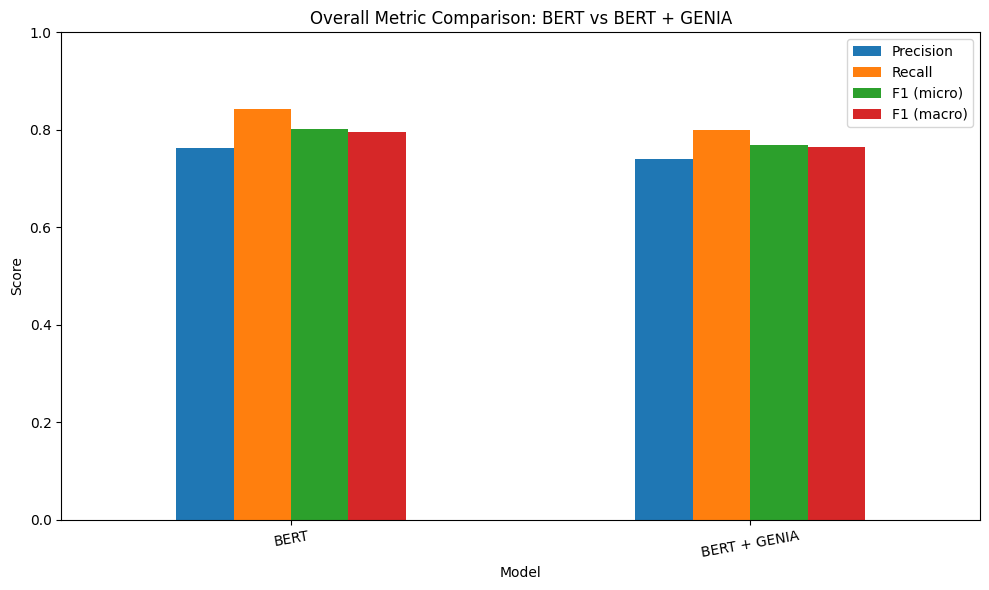

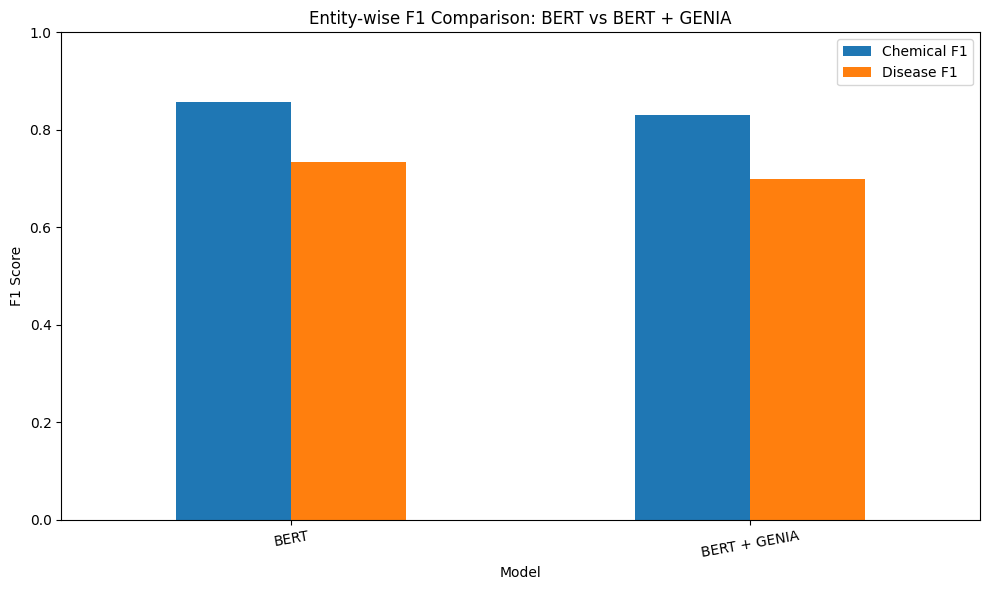

In [ ]:
plot_df = results_df.set_index("Model")[["Precision", "Recall", "F1 (micro)", "F1 (macro)"]]
ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Overall Metric Comparison: BERT vs BERT + GENIA")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

entity_df = results_df.set_index("Model")[["Chemical F1", "Disease F1"]]
ax = entity_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Entity-wise F1 Comparison: BERT vs BERT + GENIA")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


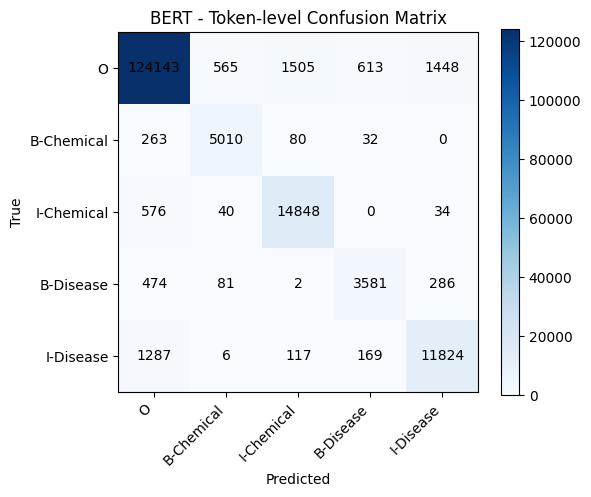

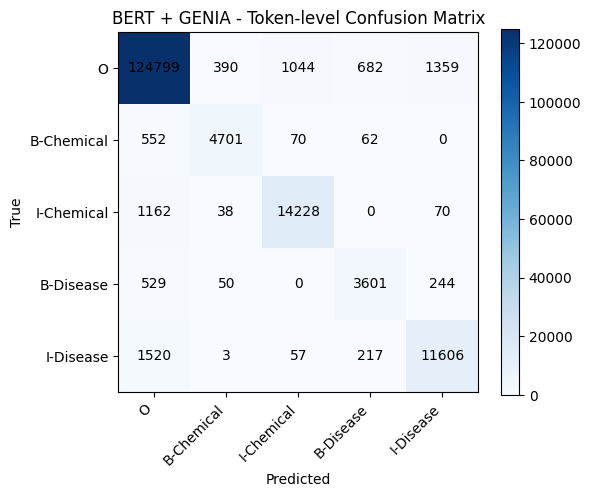

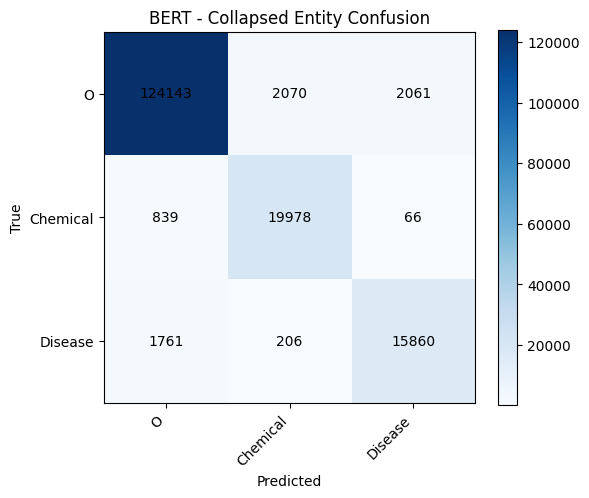

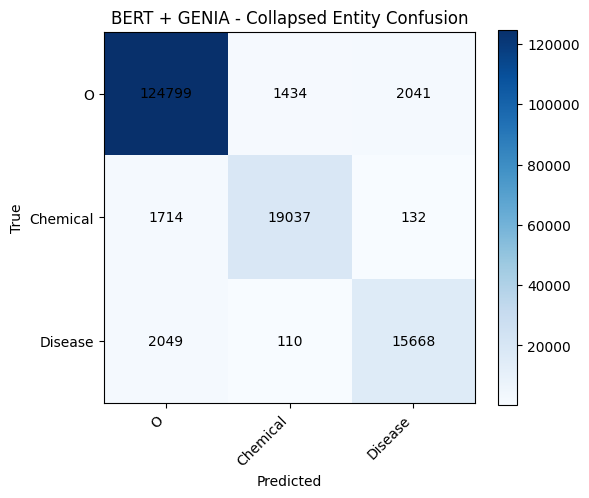

In [ ]:
labels_full = ["O", "B-Chemical", "I-Chemical", "B-Disease", "I-Disease"]

plot_confusion_matrix_simple(bert_true, bert_pred, labels_full, "BERT - Token-level Confusion Matrix")
plot_confusion_matrix_simple(bertg_true, bertg_pred, labels_full, "BERT + GENIA - Token-level Confusion Matrix")

bert_true_c = [collapse_entity(x) for x in bert_true]
bert_pred_c = [collapse_entity(x) for x in bert_pred]
bertg_true_c = [collapse_entity(x) for x in bertg_true]
bertg_pred_c = [collapse_entity(x) for x in bertg_pred]

labels_collapsed = ["O", "Chemical", "Disease"]

plot_confusion_matrix_simple(bert_true_c, bert_pred_c, labels_collapsed, "BERT - Collapsed Entity Confusion")
plot_confusion_matrix_simple(bertg_true_c, bertg_pred_c, labels_collapsed, "BERT + GENIA - Collapsed Entity Confusion")


## Step 9: Effect of GENIA Augmentation



,Base Model,Micro F1 Gain,Macro F1 Gain,Chemical F1 Gain,Disease F1 Gain
0,BERT,-0.0325,-0.0304,-0.0266,-0.0342


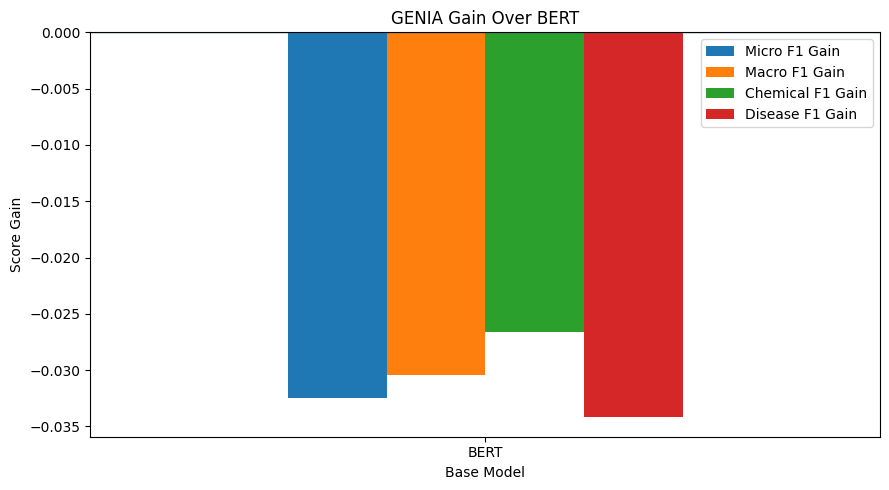

In [ ]:
improvement_df = pd.DataFrame({
    "Base Model": ["BERT"],
    "Micro F1 Gain": [
        bert_genia_test_results["eval_f1_micro"] - bert_test_results["eval_f1_micro"]
    ],
    "Macro F1 Gain": [
        bert_genia_test_results["eval_f1_macro"] - bert_test_results["eval_f1_macro"]
    ],
    "Chemical F1 Gain": [
        bert_genia_test_results["eval_Chemical_f1"] - bert_test_results["eval_Chemical_f1"]
    ],
    "Disease F1 Gain": [
        bert_genia_test_results["eval_Disease_f1"] - bert_test_results["eval_Disease_f1"]
    ]
}).round(4)

display(improvement_df)

ax = improvement_df.set_index("Base Model").plot(kind="bar", figsize=(9, 5))
ax.set_title("GENIA Gain Over BERT")
ax.set_ylabel("Score Gain")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 10: Error Analysis



In [ ]:
examples_shown = 0
print("=" * 100)
print("Examples where BERT failed but BERT + GENIA succeeded")
print("=" * 100)

for i in range(len(test_data)):
    tokens = test_data[i]["tokens"]
    actual_tags = test_data[i]["labels"]

    bert_word_preds = reconstruct_tags(bert_preds[i], bert_dataset["test"][i]["labels"], label_names)
    bert_genia_word_preds = reconstruct_tags(bert_genia_preds[i], bert_dataset["test"][i]["labels"], label_names)

    if len(bert_word_preds) != len(tokens) or len(bert_genia_word_preds) != len(tokens):
        continue

    bert_correct = (bert_word_preds == actual_tags)
    bert_genia_correct = (bert_genia_word_preds == actual_tags)

    if (not bert_correct) and bert_genia_correct:
        print(f"\nExample {examples_shown + 1}")
        print(f"{'Token':<20} | {'True':<15} | {'BERT':<15} | {'BERT+GENIA':<15}")
        print("-" * 80)
        for tk, tr, bp, bgp in zip(tokens, actual_tags, bert_word_preds, bert_genia_word_preds):
            mark = "*" if bp != tr else ""
            print(f"{tk:<20} | {tr:<15} | {bp + mark:<15} | {bgp:<15}")

        examples_shown += 1
        if examples_shown >= 10:
            break

if examples_shown == 0:
    print("No examples found.")


Examples where BERT failed but BERT + GENIA succeeded

Example 1
Token                | True            | BERT            | BERT+GENIA     
--------------------------------------------------------------------------------
The                  | O               | O               | O              
systemic             | O               | O               | O              
toxic                | O               | B-Disease*      | O              
signs                | O               | O               | O              
of                   | O               | O               | O              
both                 | O               | O               | O              
agents               | O               | O               | O              
were                 | O               | O               | O              
similar              | O               | O               | O              
and                  | O               | O               | O              
occurred             | O     